In [31]:
import pandas as pd
datos = pd.read_csv("insurance.csv")
datos.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**2.1 Calibración Teórica (MLE):** Explique conceptualmente (sin necesidad de desarrollar toda la demostración algebraica) por qué el Estimador de Máxima Verosimilitud (λˆMLE) para esta distribución corresponde a la media
aritmética de la muestra.


En una distribución de Poisson, el parámetro λ representa tanto la media como la varianza de la variable. El método de Máxima Verosimilitud (MLE) busca el valor de λ que maximiza la probabilidad de observar los datos muestrales.

Conceptualmente, el valor que mejor resume la información de los datos observados es su media aritmética. Dado que en una distribución de Poisson el valor esperado es igual a λ, el estimador de máxima verosimilitud coincide con la media de la muestra.

Por lo tanto, el estimador λ_MLE es simplemente el promedio de los datos observados.

**2. Reconstrucción Probabilística:** Calcule el λˆMLE a partir de los datos. Luego, construya una tabla comparativa
para los valores k ∈ {0, 1, 2, 3, 4, 5} que contraste la Funci´on de Masa de Probabilidad (PMF) Empírica (la proporción real en la base de datos) contra la PMF Te´orica del modelo de Poisson

In [33]:
import pandas as pd
from scipy.stats import poisson
datos = pd.read_csv("insurance.csv")
datos.head()
lambda_MLE = datos["children"].mean()
print(f"El estimador de máxima verosimilitud para λ es: {lambda_MLE}")
k_vals = [0, 1, 2, 3, 4, 5]

# 3. PMF empírica
pmf_empirica = []
pmf_empirica2=[]
n = len(datos)

for k in k_vals:
    proporcion = (datos["children"] == k).mean()
    proporcion2=len(datos[datos["children"] == k])/n
    pmf_empirica.append(proporcion)
    pmf_empirica2.append(proporcion2)

# 4. PMF teórica Poisson
pmf_teorica = [poisson.pmf(k, mu=lambda_MLE) for k in k_vals]

# 5. Tabla comparativa
tabla = pd.DataFrame({
    "k": k_vals,
    "PMF_Empirica": pmf_empirica,
    "PMF_Teorica_Poisson": pmf_teorica
})

print("Lambda MLE =", lambda_MLE)
print(tabla)
print(pmf_empirica2)


El estimador de máxima verosimilitud para λ es: 1.0949177877429
Lambda MLE = 1.0949177877429
   k  PMF_Empirica  PMF_Teorica_Poisson
0  0      0.428999             0.334567
1  1      0.242152             0.366323
2  2      0.179372             0.200547
3  3      0.117339             0.073194
4  4      0.018685             0.020035
5  5      0.013453             0.004387
[0.4289985052316891, 0.242152466367713, 0.17937219730941703, 0.11733931240657698, 0.01868460388639761, 0.013452914798206279]


**3. Auditoría y Diagnóstico:** Basado en los resultados de su tabla, emita un juicio profesional. ¿Es la distribución de Poisson un buen modelo para la estructura demográfica de esta cartera? Si detecta anomalías en el ajuste,explique matem´aticamente y desde el punto de vista del negocio qué fenómeno demográfico está ignorando el modelo paramétrico.

Al comparar la PMF empírica con la PMF teórica del modelo de Poisson, se observan diferencias importantes entre ambas distribuciones. En particular, existe un exceso de ceros en los datos reales respecto a lo que predice el modelo, ya que la proporción empírica para k=0 es significativamente mayor que la teórica.

Adicionalmente, el modelo de Poisson sobreestima la probabilidad de algunos valores intermedios (como k=1) y no captura adecuadamente la frecuencia de valores más altos. Estas discrepancias indican que el modelo no logra reproducir correctamente la estructura de la variable.

Desde el punto de vista teórico, esto sugiere que no se cumple el supuesto de equidispersión de la distribución de Poisson, donde la media es igual a la varianza. La presencia de exceso de ceros y diferencias en la dispersión indica que la varianza real es distinta de la media.

Desde el punto de vista del negocio, esto puede reflejar que existen distintos perfiles de pólizas (por ejemplo, familias sin hijos y familias con varios dependientes), lo cual no es capturado por un modelo Poisson simple.

Por lo tanto, se concluye que la distribución de Poisson no es un modelo adecuado para describir completamente la estructura de la variable children.

In [3]:
import pandas as pd
datos = pd.read_csv("insurance.csv")
datos.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### **3.1 Evidencia Poblacional:** Trace un histograma de la variable charges para demostrar visualmente por qué el analista junior concluyó que la población es asimétrica.

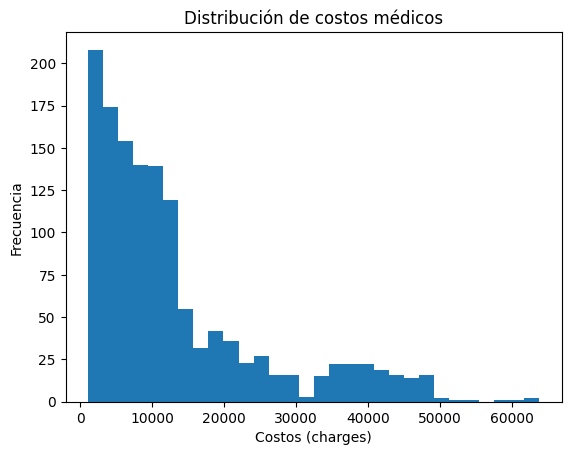

In [5]:
import matplotlib.pyplot as plt

plt.hist(datos["charges"], bins=30)
plt.title("Distribución de costos médicos")
plt.xlabel("Costos (charges)")
plt.ylabel("Frecuencia")
plt.show()

In [24]:
mayores_15000 = datos[datos["charges"] > 15000]
probabilidad_mayores_15000 = len(mayores_15000)/len(datos)
print(f"La probabilidad de que el costo promedio supere los $15,000 es: {probabilidad_mayores_15000*100}%")


La probabilidad de que el costo promedio supere los $15,000 es: 26.756352765321374%


#### **3.2 Simulación de Monte Carlo:** Construya un experimento computacional extrayendo 5,000 muestras aleatorias(con reemplazo), cada una de tamaño n = 40, de la base de datos original. Calcule la media de cada muestra y grafique la distribución resultante de estas medias muestrale

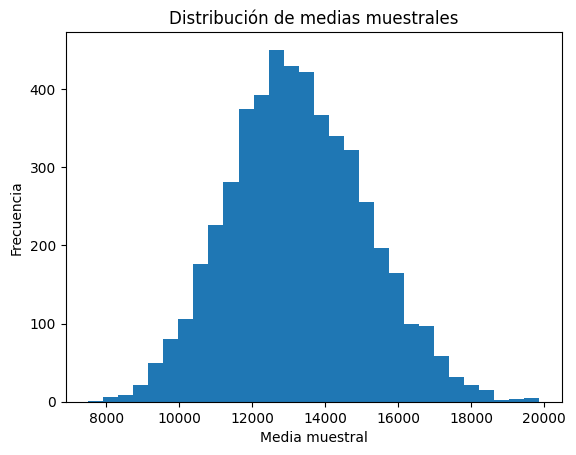

In [13]:
import numpy as np
medias = []
for i in range(5000):
    muestra = datos["charges"].sample(n=40, replace=True)
    media = muestra.mean()
    medias.append(media)

plt.hist(medias, bins=30)
plt.title("Distribución de medias muestrales")
plt.xlabel("Media muestral")
plt.ylabel("Frecuencia")
plt.show()
#### **3. Distribución de muestreo:** Calcule la media y la desviación estándar de la distribución de muestreo de las medias muestrales.
media_muestral = np.mean(medias)


**3.3.1 Calcule la probabilidad** empírica de que el costo promedio supere los $15,000 utilizando los resultados de su simulación

In [15]:
mayores_15000=0
for i in range(5000):
    if medias[i] > 15000:
        mayores_15000+=1
probabilidad = mayores_15000/5000
print(f"La probabilidad empírica de que el costo promedio supere los $15,000 es: {probabilidad*100}%")

La probabilidad empírica de que el costo promedio supere los $15,000 es: 17.98%


**3.3.2 Calcule esta misma probabilidad** asumiendo una aproximación paramétrica teórica.


In [23]:
import scipy.stats as stats
mu = datos["charges"].mean()
print(f"La media de la población es: {mu}")

sigma = datos["charges"].std()
print(f"La desviación estándar de la población es: {sigma}")

error_estandar = sigma/np.sqrt(40)
print(f"El error estándar de la media muestral es: {error_estandar}")

Z = (15000 - mu)/error_estandar
print(f"El valor de Z es: {Z}")

probabilidad_teorica = 1 - stats.norm.cdf(Z)
print(f"La probabilidad teórica de que el costo promedio supere los $15,000 es: {probabilidad_teorica*100}%")




La media de la población es: 13270.422265141257
La desviación estándar de la población es: 12110.011236694001
El error estándar de la media muestral es: 1914.7608999092743
El valor de Z es: 0.9032865330291081
La probabilidad teórica de que el costo promedio supere los $15,000 es: 18.31869210108714%


El analista tiene razón en que la variable **charges (costos médicos individuales)** no sigue una **distribución normal y presenta asimetría**. 

Sin embargo, el problema no se enfoca en datos individuales sino en el promedio aleatorio de 40 siniestros. **La simulación muestra que la distribución de las medias se aproxima a una forma normal**.

Esto se explica por el teorema del límite central, el cual establece que aunque la población no sea normal, **la distribución de las medias muestrales tiende a ser normal** cuando el tamaño de la muestra es suficientemente grande.